In [1]:
!pip install faker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 22.4 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from faker import Faker
import random

In [3]:
fake = Faker()
Faker.seed(42)

data = []

for i in range(10000):
    gender = random.choice(["Male", "Female"])

    patient = {
        "Patient_ID": i+1,
        "Name": fake.name(),
        "Age": random.randint(20, 80),
        "Gender": gender,
        "Blood_Pressure": random.randint(80, 180),
        "Sugar_Level": random.randint(70, 200),
        "Cholesterol": random.randint(150, 300),
        "Heart_Rate": random.randint(60, 120)
    }

    data.append(patient)

df = pd.DataFrame(data)
df.head()

,Patient_ID,Name,Age,Gender,Blood_Pressure,Sugar_Level,Cholesterol,Heart_Rate
0,1,Allison Hill,75,Female,106,153,224,88
1,2,Noah Rhodes,71,Female,97,121,256,94
2,3,Angie Henderson,57,Female,122,156,269,90
3,4,Daniel Wagner,31,Female,126,172,204,85
4,5,Cristian Santos,28,Female,107,93,233,96


In [4]:
print(df.isnull().sum())
df["Gender"] = df["Gender"].map({"Male": 0, "Female": 1})
df.info()

Patient_ID        0
Name              0
Age               0
Gender            0
Blood_Pressure    0
Sugar_Level       0
Cholesterol       0
Heart_Rate        0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Patient_ID      10000 non-null  int64 
 1   Name            10000 non-null  object
 2   Age             10000 non-null  int64 
 3   Gender          10000 non-null  int64 
 4   Blood_Pressure  10000 non-null  int64 
 5   Sugar_Level     10000 non-null  int64 
 6   Cholesterol     10000 non-null  int64 
 7   Heart_Rate      10000 non-null  int64 
dtypes: int64(7), object(1)
memory usage: 625.1+ KB


In [5]:
def risk_level(row):
    if (row["Blood_Pressure"] > 140 or
        row["Sugar_Level"] > 160 or
        row["Cholesterol"] > 240):
        return "High"
    elif (row["Blood_Pressure"] > 120 or
          row["Sugar_Level"] > 120 or
          row["Cholesterol"] > 200):
        return "Medium"
    else:
        return "Low"

df["Risk_Level"] = df.apply(risk_level, axis=1)

df.head()

,Patient_ID,Name,Age,Gender,Blood_Pressure,Sugar_Level,Cholesterol,Heart_Rate,Risk_Level
0,1,Allison Hill,75,1,106,153,224,88,Medium
1,2,Noah Rhodes,71,1,97,121,256,94,High
2,3,Angie Henderson,57,1,122,156,269,90,High
3,4,Daniel Wagner,31,1,126,172,204,85,High
4,5,Cristian Santos,28,1,107,93,233,96,Medium


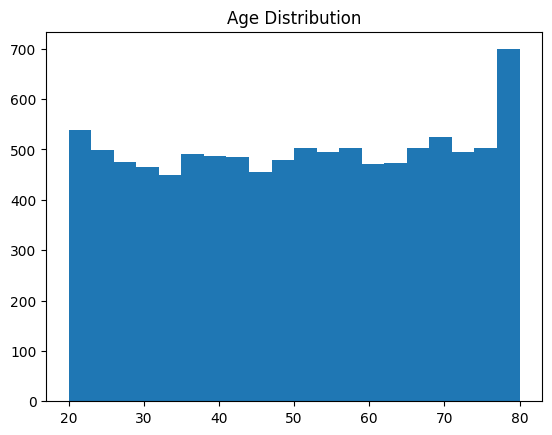

In [6]:
plt.hist(df["Age"], bins=20)
plt.title("Age Distribution")
plt.show()

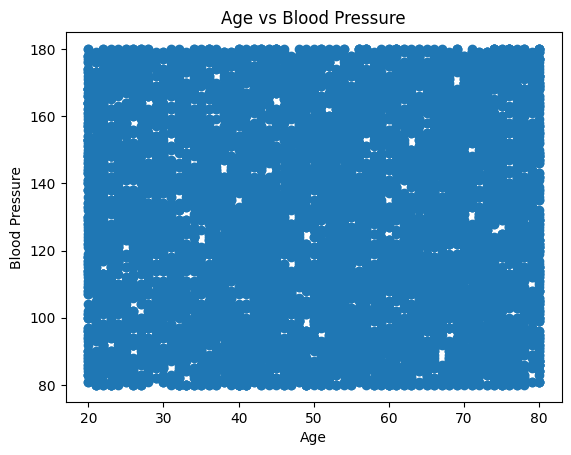

In [7]:
plt.scatter(df["Age"], df["Blood_Pressure"])
plt.xlabel("Age")
plt.ylabel("Blood Pressure")
plt.title("Age vs Blood Pressure")
plt.show()

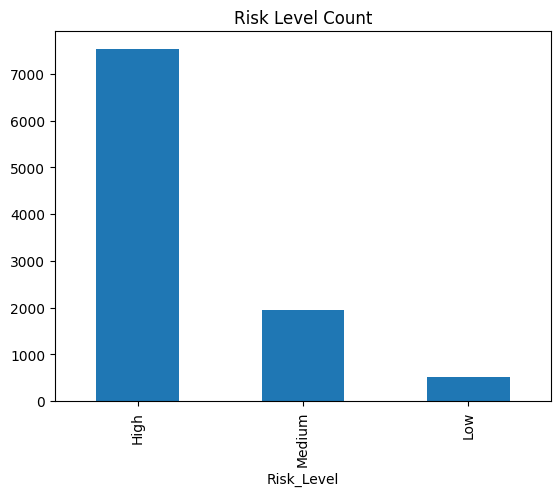

In [8]:
df["Risk_Level"].value_counts().plot(kind="bar")
plt.title("Risk Level Count")
plt.show()

In [10]:
print(df.groupby("Gender")["Blood_Pressure"].mean())
df["Age_Group"] = pd.cut(df["Age"], bins=[20,30,40,50,60,70,80])
print(df.groupby("Age_Group")["Risk_Level"].value_counts())

Gender
0    130.190871
1    129.690626
Name: Blood_Pressure, dtype: float64
Age_Group  Risk_Level
(20, 30]   High          1251
           Medium         325
           Low             90
(30, 40]   High          1196
           Medium         320
           Low             69
(40, 50]   High          1206
           Medium         282
           Low             87
(50, 60]   High          1228
           Medium         345
           Low             75
(60, 70]   High          1278
           Medium         313
           Low             81
(70, 80]   High          1252
           Medium         349
           Low             97
Name: count, dtype: int64


/tmp/ipykernel_2336/3594217089.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("Age_Group")["Risk_Level"].value_counts())


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

X = df[["Age", "Gender", "Blood_Pressure", "Sugar_Level", "Cholesterol", "Heart_Rate"]]
y = df["Risk_Level"]

le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [12]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [13]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


In [14]:
new_patient = pd.DataFrame({
    "Age": [60],
    "Gender": [1],
    "Blood_Pressure": [150],
    "Sugar_Level": [170],
    "Cholesterol": [260],
    "Heart_Rate": [85]
})

pred = model.predict(new_patient)
print("Predicted Risk:", le.inverse_transform(pred)[0])

Predicted Risk: High


In [15]:
df.to_csv("faker_healthcare_data.csv", index=False)